# **Mount Drive**

# **Sankey**

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import geopandas as gpd
from matplotlib import pyplot as plt
import seaborn as sns
from glob import glob

In [ ]:
fpath1 = '<DATA_ROOT>/WeatherIndex/Temp_Tercile_11nov.csv'
fpath2 = '<DATA_ROOT>/WeatherIndex/Drought_Map.csv'
dft = pd.read_csv(fpath1)
dfd = pd.read_csv(fpath2)
# dfd

dft = dft.rename(columns={'Year':'year'})

dfd = dfd.rename(columns={'Year':'year', 'STATE':'State', 'COUNTY':'County'})
fpath = '<DATA_ROOT>/WeatherIndex/svi2020fips.csv'
df_fips_obj = pd.read_csv(fpath)[['FIPS',	'OBJECTID']]
dfd = pd.merge(dfd,df_fips_obj,on=['OBJECTID'])
dfd.iloc[0:5,:]

# formatted_numbers = [str(n).zfill(5) for n in dfd['FIPS'].values]
# dfd['FIPS'] = formatted_numbers


In [ ]:
import pandas as pd
fsvi = '<DATA_ROOT>/SVI/SVI_timeseries.csv'
df_svi = pd.read_csv(fsvi)
# df_svi = df_svi.sort_values(by=['State', 'County'])
df_svi = df_svi.drop(columns=['State', 'County'])
df_svi = df_svi.set_index(['FIPS','year'])
# df_svi

In [ ]:
# df_svi = df_svi.set_index(['FIPS','year'])
bins = [0, 0.25, 0.5, 0.75, 1]
labels = [1, 2, 3, 4]
df_svi = df_svi.apply(lambda x: pd.cut(x, bins=bins, labels=labels), axis=0)
# df_svi = df_svi.reset_index()
# df_svi

In [ ]:
ffail = '<DATA_ROOT>/crop_failure_data/crops_failure_0595.csv'
df_fail = pd.read_csv(ffail)
df_fail = df_fail.drop(columns=['Unnamed: 0'])
df_fail = df_fail.sort_values(by=['FIPS'])
# cond1 = df_fail['year']>2011
cond2 = df_fail['Planted Acres'] > 0
df_fail = df_fail[cond2]
df_fail['fail_share'] = df_fail['Failed Acres'] /  df_fail['Planted Acres']
df_fail = df_fail[df_fail.fail_share < 1]
df_fail.iloc[0:10,:]

In [ ]:
# df_fail_agg = df_fail.groupby(['FIPS','Crop','year','Irrigation Practice']).mean().reset_index()
df_merge = pd.merge(df_fail,df_svi['RPL_THEMES'],on=['FIPS','year'])
df_merge = pd.merge(df_merge,dfd,on=['FIPS','year'])
df_merge = df_merge[['FIPS', 'year', 'Crop', 'Irrigation Practice', 'fail_share', 'RPL_THEMES', 'SPEI9']]
df_merge.loc[df_merge['SPEI9'] == 0,'SPEI9'] = 1
# df_merge = df_merge[df_merge['Irrigation Practice'] != 'ALL']
df_merge#[df_merge['SPEI9'] == 1]
df_merge = df_merge[df_merge.fail_share > 0]
df_merge

In [ ]:
df = df_merge
df1 = df.groupby(['Irrigation Practice' , 'Crop'])['fail_share'].count().reset_index()
df1.columns = ['source', 'target', 'value']

df2 = df.groupby(['Crop' , 'SPEI9'])['fail_share'].count().reset_index()
df2.columns = ['source', 'target', 'value']

df1['source'] = df1.source.map({'I': 'Irigation', 'N': 'Rainfed'})
df2['target'] = df2.target.map({-1: 'Non-Drought', 1: 'Drought'})
links = pd.concat([df1, df2], axis=0)
unique_source_target = list(pd.unique(links[['source', 'target']].values.ravel('K')))
mapping_dict = {k: v for v, k in enumerate(unique_source_target)}
links['source'] = links['source'].map(mapping_dict)
links['target'] = links['target'].map(mapping_dict)

links_dict = links.to_dict(orient='list')
import plotly.graph_objects as go
import pandas as pd
color_palette0 = ['#8080ff','#ff6666']
color_palette1 = ['rgba(0,0,255, 0.35)'] * 8
color_palette2 = ['rgba(255,0,0, 0.35)'] * 8
color_palette3 = ['#737373'] * 8
color_palette4 = ['rgba(0,0,255, 0.35)','rgba(255,0,0, 0.35)'] * 8
color_palette5 = ['#8080ff','#ff6666']


fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=unique_source_target,
        color = color_palette0 + color_palette3 + color_palette5,
    ),
    link=dict(
        source=links_dict["source"],
        target=links_dict["target"],
        value=links_dict["value"],
        color = color_palette1 + color_palette2 + color_palette4
    )
)])

fig.update_layout(
    title_text="Failure Share",
    # font_family="Courier New",
    font_color="black",
    font_size=12,
    # title_font_family="Times New Roman",
    # title_font_color="blue",
    title_font_size=18,
)
fig.show()


In [ ]:
# df_merge

In [ ]:
ClimReg_dir = '<DATA_ROOT>/US_ClimateRegions/US_ClimateRegions/'
gdf_clim = gpd.read_file(ClimReg_dir)
gdf_clim

In [ ]:
fpath_counties_clim = '<DATA_ROOT>/US_ClimateRegions/Counties_ClimReg.csv'
df_counties_clim = pd.read_csv(fpath_counties_clim)
df_counties_clim = df_counties_clim.drop(columns=['Unnamed: 0',	'State', 	'County'])
df_counties_clim

In [ ]:
df_merge_clim = pd.merge(df_merge,df_counties_clim,on='FIPS')
df_merge_clim

In [ ]:
df = df_merge_clim
df1 = df.groupby(['Irrigation Practice' , 'ClimRegNam'])['fail_share'].count().reset_index()
df1.columns = ['source', 'target', 'value']

df2 = df.groupby(['ClimRegNam' , 'Crop'])['fail_share'].count().reset_index()
df2.columns = ['source', 'target', 'value']

df3 = df.groupby(['Crop' , 'SPEI9'])['fail_share'].count().reset_index()
df3.columns = ['source', 'target', 'value']

df1['source'] = df1.source.map({'I': 'Irrigation', 'N': 'Rainfed'})
df3['target'] = df3.target.map({-1: 'Non-Drought', 1: 'Drought'})

links = pd.concat([df1, df2, df3], axis=0)
unique_source_target = list(pd.unique(links[['source', 'target']].values.ravel('K')))
mapping_dict = {k: v for v, k in enumerate(unique_source_target)}
links['source'] = links['source'].map(mapping_dict)
links['target'] = links['target'].map(mapping_dict)

links_dict = links.to_dict(orient='list')
import plotly.graph_objects as go
import pandas as pd
# color_palette0 = ['#8080ff','#ff6666']
# color_palette1 = ['rgba(0,0,255, 0.35)'] * 8
# color_palette2 = ['rgba(255,0,0, 0.35)'] * 8
# color_palette3 = ['#737373'] * 8
# color_palette4 = ['rgba(0,0,255, 0.35)','rgba(255,0,0, 0.35)'] * 8
# color_palette5 = ['#8080ff','#ff6666']


fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=unique_source_target,
        # color = color_palette0 + color_palette3 + color_palette5,
    ),
    link=dict(
        source=links_dict["source"],
        target=links_dict["target"],
        value=links_dict["value"],
        # color = color_palette1 + color_palette2 + color_palette4
    )
)])

fig.update_layout(
    title_text="Failure Count",
    # font_family="Courier New",
    font_color="black",
    font_size=12,
    # title_font_family="Times New Roman",
    # title_font_color="blue",
    title_font_size=18,
)
fig.show()


# **Cimate Region**

In [ ]:
df_merge_clim = pd.merge(df_merge,df_counties_clim,on='FIPS')
# grp_cols1 = ['Crop', 'Irrigation Practice', 'RPL_THEMES', 'SPEI9', 'ClimRegNam']
grp_cols1 = ['ClimRegNam', 'Irrigation Practice', 'Crop', 'RPL_THEMES']
df_merge_clim = df_merge_clim.drop(columns=['year', 	'ClimRegCod'])
# df_group = df_merge_clim.groupby(grp_cols1).sum().reset_index()
df_group1 = df_merge_clim.groupby(grp_cols1).count()#.reset_index()

grp_cols2 = ['FIPS','Irrigation Practice','Crop','RPL_THEMES']
df_group2 = df_merge_clim.groupby(grp_cols2).first().dropna().reset_index()
grp_cols2 = ['ClimRegNam','Irrigation Practice','Crop','RPL_THEMES']
df_group2 = df_group2.groupby(grp_cols2).count()#.reset_index()

df_group = df_group1 / df_group2
df_group = df_group.reset_index()


In [ ]:
cond = df_group['Irrigation Practice'] == 'ALL'
df_group = df_group[cond]
df_group


In [ ]:
# cond = df_group['ClimRegNam'] == 'Northeast'
# df_group_i = df_group[cond]
# df_group_i.pivot(index='Crop',columns='RPL_THEMES',values='fail_share')


clims = list(df_group['ClimRegNam'].unique())
for clim in clims:
  cond = df_group['ClimRegNam'] == clim
  df_group_i = df_group[cond]
  df_pivot = df_group_i.pivot(index='Crop',columns='RPL_THEMES',values='fail_share')

  colors =['#F4A460','#D2691E','#8B4513','#800000']
  df_pivot.plot.bar(figsize=(9, 6),width=0.7,color=colors,legend=False)
  x_list = list(df_pivot.index)
  plt.xticks(np.arange(0,8) ,  x_list , rotation=45, ha='right' , fontsize=12)
  plt.yticks(fontsize=12)
  plt.xlabel('')
  # plt.title(f'{crop} {ig_type} {theme} {dr_type}')
  plt.title(f'{clim}')

  out_path = '<DATA_ROOT>/Final_Exports/20231120-Section2/20231120-GroupBarChart-FailEventDensClimRegAllCrops/'
  plt.savefig(out_path + clim +'.tiff')
  plt.close()


In [ ]:
crops = ['CORN', 'COTTON', 'OATS', 'SORGHUM', 'SOYBEANS', 'WHEAT', 'BARLEY', 'HAY']
theme = 'RPL_THEMES'
for crop in crops:
  for ig in ['ALL' , 'I' , 'N']:
    ig_type = 'Irrigation'
    if ig == 'N':
      ig_type = 'Rainfed'
    if ig == 'ALL':
      ig_type = 'ALL_Irrigation'
    # for dr in [-1,1]:
    for dr in [1]:
      dr_type = 'Drought'
      if dr == -1:
        dr_type = 'Non-Drought'
      cond_crop = df_group['Crop'] == crop
      cond_ig = df_group['Irrigation Practice'] == ig
      # cond_dr = df_group['SPEI9'] == dr
      # df_group_i = df_group[cond_crop & cond_ig & cond_dr]
      df_group_i = df_group[cond_crop & cond_ig]

      df_pivot = df_group_i.pivot(index='ClimRegNam',columns=theme,values='fail_share').sort_index()
      colors = ['#d7191c','#fdae61','#abd9e9','#2c7bb6'][::-1]
      df_pivot.plot.bar(figsize=(9, 6),width=0.7,color=colors,legend=False)
      x_list = ['NE','WNC','NW' , 'C' , 'S' , 'SE' , 'SW' , 'ENC' , 'W' ]
      plt.xticks(np.arange(0,9) ,  x_list , rotation=45, ha='right' , fontsize=12)
      plt.yticks(fontsize=12)
      plt.xlabel('')
      # plt.title(f'{crop} {ig_type} {theme} {dr_type}')
      plt.title(f'{crop} {ig_type} {theme}')

      # out_path = '<DATA_ROOT>/ProcessedData/20231120-GroupBarChart-FailEventDensClimReg/'
      # # plt.savefig(out_path + crop + '_' + theme + '_' + ig_type + '_' + dr_type +'.jpg')
      # plt.savefig(out_path + crop + '_' + theme + '_' + ig_type +'.tiff')
      # plt.close()

In [ ]:
df_group = df_group[df_group['SPEI9'] == 1]
df_group = df_group[df_group['Irrigation Practice'] == 'I']
cond_crop = df_group['Crop'] == 'WHEAT'
df_group = df_group[cond_crop]


In [ ]:
df_pivot.sort_index()

RPL_THEMES,1,2,3,4
ClimRegNam,,,,
Northeast,0.013134,0.110912,0.027338,0.051928
Northern Rockies and Plains,0.159910,0.096500,0.099343,0.209862
Northwest,0.044245,0.008252,0.028818,0.033496
Ohio Valley,0.198266,0.140312,0.067948,0.056772
South,0.080539,0.106716,0.093189,0.106514
Southeast,NaN,NaN,0.003268,0.052224
Southwest,0.194804,0.044324,0.085188,0.050872
Upper Midwest,0.244438,0.178168,0.250324,NaN
West,NaN,0.016909,0.021569,0.036111


In [ ]:
df_merge_clim = pd.merge(df_merge,df_counties_clim,on='FIPS')
# grp_cols1 = ['Crop', 'Irrigation Practice', 'RPL_THEMES', 'SPEI9', 'ClimRegNam']
grp_cols1 = ['ClimRegNam', 'Irrigation Practice', 'Crop', 'RPL_THEMES']
df_merge_clim = df_merge_clim.drop(columns=['year', 	'ClimRegCod'])
# df_group = df_merge_clim.groupby(grp_cols1).sum().reset_index()
df_group1 = df_merge_clim.groupby(grp_cols1).count()#.reset_index()

grp_cols2 = ['FIPS','Irrigation Practice','Crop','RPL_THEMES']
df_group2 = df_merge_clim.groupby(grp_cols2).first().dropna().reset_index()
grp_cols2 = ['ClimRegNam','Irrigation Practice','Crop','RPL_THEMES']
df_group2 = df_group2.groupby(grp_cols2).count()#.reset_index()

df_group = df_group1 / df_group2
df_group = df_group.reset_index()

# df_merge_clim = pd.merge(df_merge,df_counties_clim,on='FIPS')
cond = df_group['Irrigation Practice'] == 'ALL'
df_group_new = df_group[cond]
# df_merge_clim = df_group[cond].groupby(['ClimRegNam','Crop','RPL_THEMES']).count().reset_index()
df_group_new[df_group_new['RPL_THEMES'] < 3]['RPL_THEMES'] = 1
df_group_new[df_group_new['RPL_THEMES'] > 2]['RPL_THEMES'] = 2
df_group_new1 = df_group_new[df_group_new['RPL_THEMES'] == 1]
df_group_new2 = df_group_new[df_group_new['RPL_THEMES'] == 2]
df_group_new1 = df_group_new1.set_index(['ClimRegNam','Crop'])['fail_share']
df_group_new2 = df_group_new2.set_index(['ClimRegNam','Crop'])['fail_share']
df_diff = df_group_new2 / df_group_new1
# df_diff.reset_index()



<Axes: xlabel='ClimRegNam,Crop'>

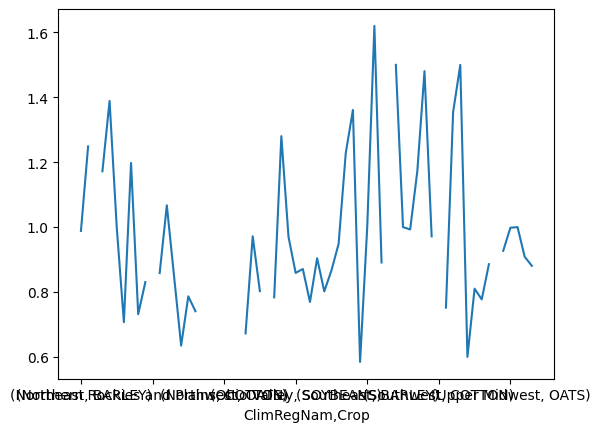

In [ ]:
df_diff.plot()

<Axes: >

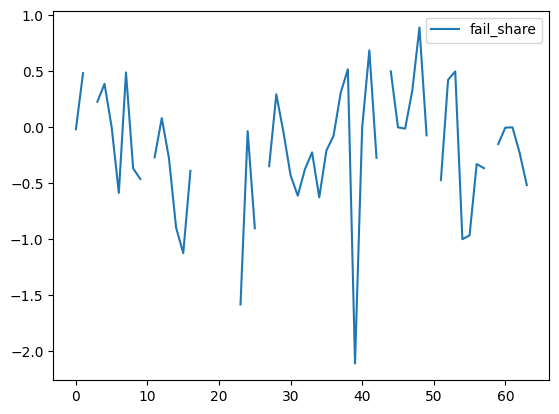

In [ ]:
df_diff.reset_index().plot()

Text(0.5, 1.0, 'WHEAT Irrigation Drought')

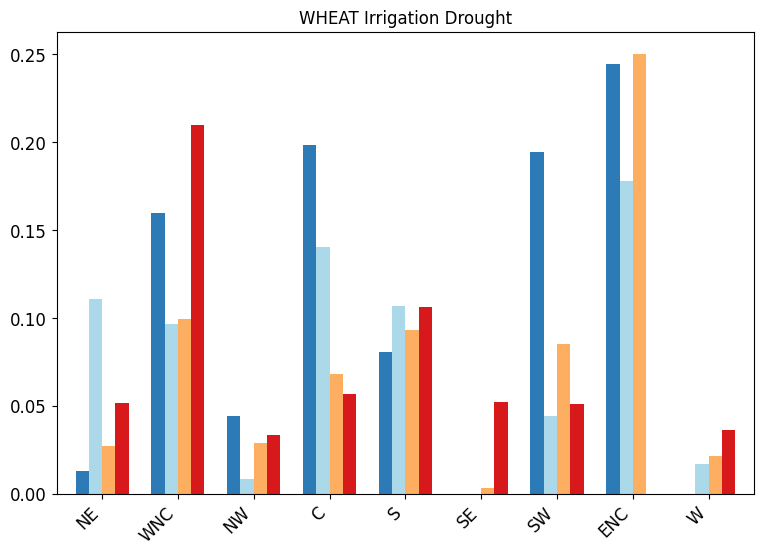

In [ ]:
colors = ['#d7191c','#fdae61','#abd9e9','#2c7bb6'][::-1]
df_pivot = df_group.pivot(index='ClimRegNam',columns='RPL_THEMES',values='fail_share')
df_pivot.plot.bar(figsize=(9, 6),width=0.7,color=colors,legend=False)
x_list = ['NE','WNC','NW' , 'C' , 'S' , 'SE' , 'SW' , 'ENC' , 'W' ]
plt.xticks(np.arange(0,9) ,  x_list , rotation=45, ha='right' , fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('')
plt.title('WHEAT Irrigation Drought')

# **HeatMap Drought**

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import geopandas as gpd
from matplotlib import pyplot as plt
import seaborn as sns
from glob import glob

In [ ]:
fpath1 = '<DATA_ROOT>/WeatherIndex/Temp_Tercile_11nov.csv'
fpath2 = '<DATA_ROOT>/WeatherIndex/Drought_Map.csv'
dft = pd.read_csv(fpath1)
dfd = pd.read_csv(fpath2)
# dfd

dft = dft.rename(columns={'Year':'year'})

dfd = dfd.rename(columns={'Year':'year', 'STATE':'State', 'COUNTY':'County'})
fpath = '<DATA_ROOT>/WeatherIndex/svi2020fips.csv'
df_fips_obj = pd.read_csv(fpath)[['FIPS',	'OBJECTID']]
dfd = pd.merge(dfd,df_fips_obj,on=['OBJECTID'])
dft.iloc[0:5,:]

In [ ]:
import pandas as pd
fsvi = '<DATA_ROOT>/SVI/SVI_timeseries.csv'
df_svi = pd.read_csv(fsvi)
# df_svi = df_svi.sort_values(by=['State', 'County'])
df_svi = df_svi.drop(columns=['State', 'County'])
df_svi = df_svi.set_index(['FIPS','year'])
# df_svi

In [ ]:
# df_svi = df_svi.set_index(['FIPS','year'])
bins = [0, 0.25, 0.5, 0.75, 1]
labels = [1, 2, 3, 4]
df_svi = df_svi.apply(lambda x: pd.cut(x, bins=bins, labels=labels), axis=0)
# df_svi = df_svi.reset_index()
# df_svi

In [ ]:
ffail = '<DATA_ROOT>/crop_failure_data/crops_failure_0595.csv'
df_fail = pd.read_csv(ffail)
df_fail = df_fail.drop(columns=['Unnamed: 0'])
df_fail = df_fail.sort_values(by=['FIPS'])
# cond1 = df_fail['year']>2011
cond2 = df_fail['Planted Acres'] > 0
df_fail = df_fail[cond2]
df_fail['fail_share'] = df_fail['Failed Acres'] /  df_fail['Planted Acres']
df_fail = df_fail[df_fail.fail_share < 1]
df_fail.iloc[0:10,:]

In [ ]:
# df_fail_agg = df_fail.groupby(['FIPS','Crop','year','Irrigation Practice']).mean().reset_index()
df_merge = pd.merge(df_fail,df_svi['RPL_THEMES'],on=['FIPS','year'])
df_merge = pd.merge(df_merge,dfd['SPEI9'],on=['FIPS','year'])
df_merge = df_merge[['FIPS', 'year', 'Crop', 'Irrigation Practice', 'fail_share', 'RPL_THEMES', 'SPEI9']]
df_merge.loc[df_merge['SPEI9'] == 0,'SPEI9'] = 1
df_merge = df_merge[df_merge['Irrigation Practice'] != 'ALL']
df_merge#[df_merge['SPEI9'] == 1]
df_merge = df_merge[df_merge.fail_share > 0]
df_merge

In [ ]:
# df_fail_agg = df_fail.groupby(['FIPS','Crop','year','Irrigation Practice']).mean().reset_index()
df_merge = pd.merge(df_fail,df_svi,on=['FIPS','year'])
df_merge = pd.merge(df_merge,dfd['SPEI9'],on=['FIPS','year'])
df_merge = df_merge[['FIPS', 'year', 'Crop', 'Irrigation Practice', 'fail_share', 'SPEI9',
                     'RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4' ]]
df_merge.loc[df_merge['SPEI9'] == 0,'SPEI9'] = 1
df_merge = df_merge[df_merge['Irrigation Practice'] != 'ALL']
df_merge#[df_merge['SPEI9'] == 1]
df_merge = df_merge[df_merge.fail_share > 0]
# df_merge

In [ ]:
df_merge['Irrigation Practice'] = df_merge['Irrigation Practice'].map({'I': 'Ir', 'N': 'Rf'})
df_merge['SPEI9'] = df_merge['SPEI9'].map({-1: 'ND', 1: 'D'})
df_merge = df_merge.drop(columns=['FIPS',	'year'])


In [ ]:
df_group1 = df_merge.groupby(['Crop',	'Irrigation Practice', 'RPL_THEME1', 'SPEI9']).mean().reset_index()
df_group2 = df_merge.groupby(['Crop',	'Irrigation Practice', 'RPL_THEME2', 'SPEI9']).mean().reset_index()
df_group3 = df_merge.groupby(['Crop',	'Irrigation Practice', 'RPL_THEME3', 'SPEI9']).mean().reset_index()
df_group4 = df_merge.groupby(['Crop',	'Irrigation Practice', 'RPL_THEME4', 'SPEI9']).mean().reset_index()

df_group1['RPL_THEME1'] = 'Theme1_' + df_group1['RPL_THEME1'].astype(str)
df_group1['SVI-Drought'] = df_group1['RPL_THEME1'] + '_' + df_group1['SPEI9']
df_group1['Crop-Irrigation'] = df_group1['Crop'] + '_' + df_group1['Irrigation Practice']
df_group1 = df_group1.drop(columns=['Crop',	'Irrigation Practice', 'RPL_THEME1', 'SPEI9'])

df_group2['RPL_THEME2'] = 'Theme2_' + df_group2['RPL_THEME2'].astype(str)
df_group2['SVI-Drought'] = df_group2['RPL_THEME2'] + '_' + df_group2['SPEI9']
df_group2['Crop-Irrigation'] = df_group2['Crop'] + '_' + df_group2['Irrigation Practice']
df_group2 = df_group2.drop(columns=['Crop',	'Irrigation Practice', 'RPL_THEME2', 'SPEI9'])

df_group3['RPL_THEME3'] = 'Theme3_' + df_group3['RPL_THEME3'].astype(str)
df_group3['SVI-Drought'] = df_group3['RPL_THEME3'] + '_' + df_group3['SPEI9']
df_group3['Crop-Irrigation'] = df_group3['Crop'] + '_' + df_group3['Irrigation Practice']
df_group3 = df_group3.drop(columns=['Crop',	'Irrigation Practice', 'RPL_THEME3', 'SPEI9'])

df_group4['RPL_THEME4'] = 'Theme4_' + df_group4['RPL_THEME4'].astype(str)
df_group4['SVI-Drought'] = df_group4['RPL_THEME4'] + '_' + df_group4['SPEI9']
df_group4['Crop-Irrigation'] = df_group4['Crop'] + '_' + df_group4['Irrigation Practice']
df_group4 = df_group4.drop(columns=['Crop',	'Irrigation Practice', 'RPL_THEME4', 'SPEI9'])


df_group = pd.concat([df_group1,df_group2,df_group3,df_group4])
df_group_pivot = df_group.pivot(index='Crop-Irrigation',columns='SVI-Drought',values='fail_share')
df_group_pivot

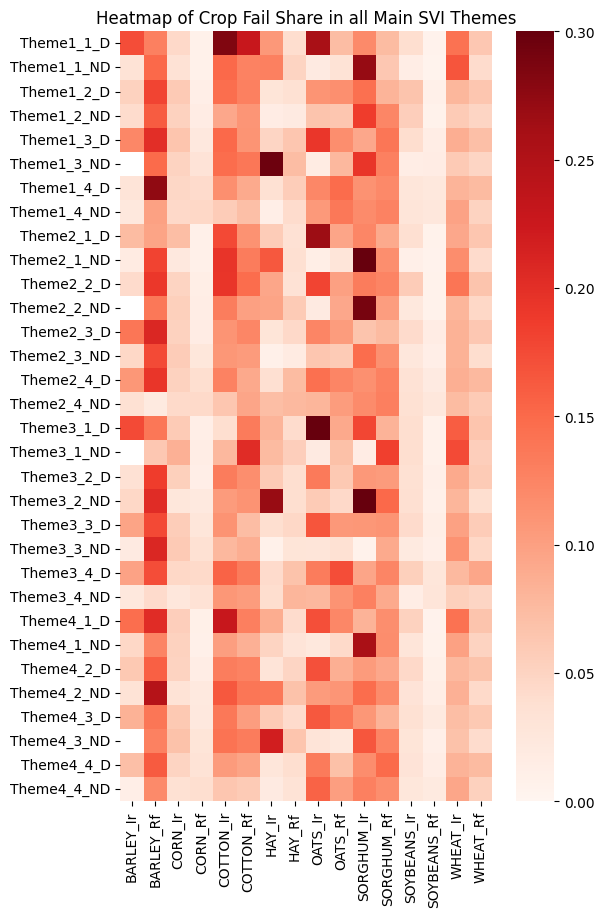

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

df_group_pivot = df_group.pivot(index='Crop-Irrigation',columns='SVI-Drought',values='fail_share')

df = df_group_pivot

colors = ['#ffffcc','#ffeda0','#fed976','#feb24c','#fd8d3c','#fc4e2a','#e31a1c','#bd0026','#800026']
cmap = ListedColormap(colors)

plt.figure(figsize=(6, 10))
# sns.heatmap(df.transpose(), cmap=cmap,vmin=0,vmax=0.2)
sns.heatmap(df.transpose(), cmap="Reds",vmin=0,vmax=0.3)
plt.title('Heatmap of Crop Fail Share in all Main SVI Themes')

plt.xlabel('')
plt.ylabel('')

plt.show()


In [ ]:
df_group1

# **HeatMap HeatWave**

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import geopandas as gpd
from matplotlib import pyplot as plt
import seaborn as sns
from glob import glob

In [ ]:
fpath1 = '<DATA_ROOT>/WeatherIndex/Temp_Tercile_11nov.csv'
fpath2 = '<DATA_ROOT>/WeatherIndex/Drought_Map.csv'
dft = pd.read_csv(fpath1)
dfd = pd.read_csv(fpath2)
# dfd

dft = dft.rename(columns={'Year':'year'})

dfd = dfd.rename(columns={'Year':'year', 'STATE':'State', 'COUNTY':'County'})
fpath = '<DATA_ROOT>/WeatherIndex/svi2020fips.csv'
df_fips_obj = pd.read_csv(fpath)[['FIPS',	'OBJECTID']]
dfd = pd.merge(dfd,df_fips_obj,on=['OBJECTID'])

dft = dft.drop(columns=['State',	'County'])
dft[dft==0] = 1
dft.iloc[0:5,:]

,FIPS,year,Thr26,Thr27,Thr28,Thr29,Thr30,Thr31,Thr32,Thr33,Thr34,Thr35,Thr36
0,1001,2009,1,-1,-1,-1,-1,1,1,1,1,1,1
1,1001,2010,1,1,1,1,1,1,1,1,1,1,1
2,1001,2011,1,1,1,1,1,1,1,1,1,1,1
3,1001,2012,-1,-1,-1,1,1,1,1,1,1,1,1
4,1001,2013,1,1,1,1,-1,1,-1,-1,1,1,1


In [ ]:
import pandas as pd
fsvi = '<DATA_ROOT>/SVI/SVI_timeseries.csv'
df_svi = pd.read_csv(fsvi)
# df_svi = df_svi.sort_values(by=['State', 'County'])
df_svi = df_svi.drop(columns=['State', 'County'])
df_svi = df_svi.set_index(['FIPS','year'])
df_svi.iloc[0:5,:]

,,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,RPL_THEME2,...,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,RPL_THEME4,RPL_THEMES,EPL_HBURD,EPL_UNINSU
FIPS,year,,,,,,,,,,,,,,,,,,,,,
1001,2009,0.3535,0.4528,0.2937,0.5251,0.3828,0.1165,0.8716,0.5786,0.7665,0.7385,...,0.5691,0.2914,0.8649,0.5191,0.2423,0.0426,0.2257,0.4426,NaN,NaN
1003,2009,0.2980,0.2617,0.1481,0.3487,0.1818,0.6127,0.3665,0.6194,0.3595,0.4751,...,0.5254,0.9366,0.6579,0.4633,0.1159,0.3716,0.5111,0.3675,NaN,NaN
1005,2009,0.9535,0.3130,0.9201,0.9092,0.8468,0.3926,0.5191,0.9079,0.9464,0.9130,...,0.8662,0.2047,0.9178,0.8149,0.9222,0.9382,0.9742,0.9589,NaN,NaN
1007,2009,0.8557,0.5203,0.8583,0.9321,0.8656,0.2098,0.5200,0.8382,0.6108,0.6391,...,0.4047,0.4423,0.9595,0.6063,0.8117,0.8576,0.9541,0.8388,NaN,NaN
1009,2009,0.4092,0.3891,0.5892,0.7735,0.5681,0.3054,0.5509,0.7961,0.1366,0.3321,...,0.6197,0.1585,0.9015,0.6375,0.2789,0.1847,0.3171,0.4878,NaN,NaN


In [ ]:
# df_svi = df_svi.set_index(['FIPS','year'])
bins = [0, 0.25, 0.5, 0.75, 1]
labels = [1, 2, 3, 4]
df_svi = df_svi.apply(lambda x: pd.cut(x, bins=bins, labels=labels), axis=0)
# df_svi = df_svi.reset_index()
df_svi[['RPL_THEMES','RPL_THEME1']].iloc[0:5,:]

,,RPL_THEMES,RPL_THEME1
FIPS,year,,
1001,2009,2,2
1003,2009,2,1
1005,2009,4,4
1007,2009,4,4
1009,2009,2,3


In [ ]:
ffail = '<DATA_ROOT>/crop_failure_data/crops_failure_0595.csv'
df_fail = pd.read_csv(ffail)
df_fail = df_fail.drop(columns=['Unnamed: 0'])
df_fail = df_fail.sort_values(by=['FIPS'])
# cond1 = df_fail['year']>2011
cond2 = df_fail['Planted Acres'] > 0
df_fail = df_fail[cond2]
df_fail['fail_share'] = df_fail['Failed Acres'] /  df_fail['Planted Acres']
df_fail = df_fail[df_fail.fail_share < 1]
df_fail.iloc[0:10,]

,FIPS,Crop,Irrigation Practice,Planted Acres,Prevented Acres,Failed Acres,State,County,year,fail_share
0,1001,CORN,ALL,1126.01,14.4,0.0,Alabama,Autauga,2009,0.000000
130,1001,CORN,I,393.17,0.0,0.0,Alabama,Autauga,2019,0.000000
131,1001,CORN,N,719.55,0.0,0.0,Alabama,Autauga,2019,0.000000
132,1001,CORN,ALL,1112.72,0.0,0.0,Alabama,Autauga,2019,0.000000
133,1001,COTTON,I,904.14,0.0,0.0,Alabama,Autauga,2019,0.000000
134,1001,COTTON,N,7154.98,0.0,48.5,Alabama,Autauga,2019,0.006778
135,1001,COTTON,ALL,8059.12,0.0,48.5,Alabama,Autauga,2019,0.006018
136,1001,OATS,N,61.38,0.0,0.0,Alabama,Autauga,2019,0.000000
137,1001,OATS,ALL,61.38,0.0,0.0,Alabama,Autauga,2019,0.000000
138,1001,SORGHUM,N,406.16,0.0,0.0,Alabama,Autauga,2019,0.000000


In [ ]:
temp_thrs = list(dft.columns)
temp_thrs.remove('FIPS')
temp_thrs.remove('year')
temp_thrs

['Thr26',
 'Thr27',
 'Thr28',
 'Thr29',
 'Thr30',
 'Thr31',
 'Thr32',
 'Thr33',
 'Thr34',
 'Thr35',
 'Thr36']

In [ ]:
# df_fail_agg = df_fail.groupby(['FIPS','Crop','year','Irrigation Practice']).mean().reset_index()
df_merge = pd.merge(df_fail,df_svi,on=['FIPS','year'])
df_merge = pd.merge(df_merge,dft,on=['FIPS','year'])
# df_merge = df_merge[['FIPS', 'year', 'Crop', 'Irrigation Practice', 'fail_share',
#                      'RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4' ] + temp_thrs]
df_merge = df_merge[['FIPS', 'year', 'Crop', 'Irrigation Practice', 'fail_share'] + temp_thrs]
# df_merge.loc[df_merge['SPEI9'] == 0,'SPEI9'] = 1
# df_merge = df_merge[df_merge['Irrigation Practice'] != 'ALL']
df_merge#[df_merge['SPEI9'] == 1]
df_merge = df_merge[df_merge.fail_share > 0]
df_merge

,FIPS,year,Crop,Irrigation Practice,fail_share,Thr26,Thr27,Thr28,Thr29,Thr30,Thr31,Thr32,Thr33,Thr34,Thr35,Thr36
10,1001,2019,COTTON,N,0.006778,1,1,1,1,1,1,1,1,1,1,1
11,1001,2019,COTTON,ALL,0.006018,1,1,1,1,1,1,1,1,1,1,1
50,1001,2017,CORN,ALL,0.020311,1,1,1,1,1,1,1,1,1,1,1
52,1001,2017,COTTON,N,0.005038,1,1,1,1,1,1,1,1,1,1,1
53,1001,2017,COTTON,ALL,0.004707,1,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381869,56045,2021,WHEAT,N,0.021856,1,1,1,1,1,1,1,1,1,1,1
381904,56045,2011,OATS,ALL,0.040159,1,1,1,1,1,1,1,1,1,1,1
381906,56045,2011,OATS,N,0.047581,1,1,1,1,1,1,1,1,1,1,1
381907,56045,2011,WHEAT,ALL,0.100136,1,1,1,1,1,1,1,1,1,1,1


In [ ]:
df_merge['Irrigation Practice'] = df_merge['Irrigation Practice'].map({'I': 'Ir', 'N': 'Rf', 'ALL':'All'})
for thr in temp_thrs:
  df_merge[thr] = df_merge[thr].map({-1: 'nHW', 1: 'HW'})
df_merge = df_merge.drop(columns=['FIPS',	'year'])
df_merge

,Crop,Irrigation Practice,fail_share,Thr26,Thr27,Thr28,Thr29,Thr30,Thr31,Thr32,Thr33,Thr34,Thr35,Thr36
10,COTTON,Rf,0.006778,HW,HW,HW,HW,HW,HW,HW,HW,HW,HW,HW
11,COTTON,All,0.006018,HW,HW,HW,HW,HW,HW,HW,HW,HW,HW,HW
50,CORN,All,0.020311,HW,HW,HW,HW,HW,HW,HW,HW,HW,HW,HW
52,COTTON,Rf,0.005038,HW,HW,HW,HW,HW,HW,HW,HW,HW,HW,HW
53,COTTON,All,0.004707,HW,HW,HW,HW,HW,HW,HW,HW,HW,HW,HW
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381869,WHEAT,Rf,0.021856,HW,HW,HW,HW,HW,HW,HW,HW,HW,HW,HW
381904,OATS,All,0.040159,HW,HW,HW,HW,HW,HW,HW,HW,HW,HW,HW
381906,OATS,Rf,0.047581,HW,HW,HW,HW,HW,HW,HW,HW,HW,HW,HW
381907,WHEAT,All,0.100136,HW,HW,HW,HW,HW,HW,HW,HW,HW,HW,HW


In [ ]:
def get_heatmap_table(df_merge , thr):
  #
  df_group1 = df_merge.groupby(['Crop',	'Irrigation Practice', 'RPL_THEME1', thr]).mean().reset_index()
  df_group2 = df_merge.groupby(['Crop',	'Irrigation Practice', 'RPL_THEME2', thr]).mean().reset_index()
  df_group3 = df_merge.groupby(['Crop',	'Irrigation Practice', 'RPL_THEME3', thr]).mean().reset_index()
  df_group4 = df_merge.groupby(['Crop',	'Irrigation Practice', 'RPL_THEME4', thr]).mean().reset_index()

  df_group1['RPL_THEME1'] = 'Theme1_' + df_group1['RPL_THEME1'].astype(str)
  df_group1['SVI-HW'] = df_group1['RPL_THEME1'] + '_' + df_group1[thr]
  df_group1['Crop-Irrigation'] = df_group1['Crop'] + '_' + df_group1['Irrigation Practice']
  df_group1 = df_group1.drop(columns=['Crop',	'Irrigation Practice', 'RPL_THEME1', thr])

  df_group2['RPL_THEME2'] = 'Theme2_' + df_group2['RPL_THEME2'].astype(str)
  df_group2['SVI-HW'] = df_group2['RPL_THEME2'] + '_' + df_group2[thr]
  df_group2['Crop-Irrigation'] = df_group2['Crop'] + '_' + df_group2['Irrigation Practice']
  df_group2 = df_group2.drop(columns=['Crop',	'Irrigation Practice', 'RPL_THEME2', thr])

  df_group3['RPL_THEME3'] = 'Theme3_' + df_group3['RPL_THEME3'].astype(str)
  df_group3['SVI-HW'] = df_group3['RPL_THEME3'] + '_' + df_group3[thr]
  df_group3['Crop-Irrigation'] = df_group3['Crop'] + '_' + df_group3['Irrigation Practice']
  df_group3 = df_group3.drop(columns=['Crop',	'Irrigation Practice', 'RPL_THEME3', thr])

  df_group4['RPL_THEME4'] = 'Theme4_' + df_group4['RPL_THEME4'].astype(str)
  df_group4['SVI-HW'] = df_group4['RPL_THEME4'] + '_' + df_group4[thr]
  df_group4['Crop-Irrigation'] = df_group4['Crop'] + '_' + df_group4['Irrigation Practice']
  df_group4 = df_group4.drop(columns=['Crop',	'Irrigation Practice', 'RPL_THEME4', thr])


  df_group = pd.concat([df_group1,df_group2,df_group3,df_group4])
  df_group_pivot = df_group.pivot(index='Crop-Irrigation',columns='SVI-HW',values='fail_share')
  return df_group_pivot


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


for thr in temp_thrs:
  df_group_pivot = get_heatmap_table(df_merge , thr)
  # df_group.pivot(index='Crop-Irrigation',columns='SVI-HW',values='fail_share')

  df = df_group_pivot
  plt.figure(figsize=(6, 10))

  # colors = ['#ffffcc','#ffeda0','#fed976','#feb24c','#fd8d3c','#fc4e2a','#e31a1c','#bd0026','#800026']
  # cmap = ListedColormap(colors)
  # sns.heatmap(df.transpose(), cmap=cmap,vmin=0,vmax=0.2)

  sns.heatmap(df.transpose(), cmap="Reds",vmin=0,vmax=0.3)
  plt.title('Heatmap of Crop Fail Share in all Main SVI Themes Temp Threshold: ' + thr)

  plt.xlabel('')
  plt.ylabel('')

  # plt.show()
  out_path = '<DATA_ROOT>/ProcessedData/20231117-Heatmap-CropFailure-SVI/'
  plt.savefig(out_path + 'Heatmap-HW-' + thr + '.png' , dpi=1200)
  plt.close()


In [ ]:
df_group_pivot.reset_index()['HW-Thr'] = thr

In [ ]:
df_group_pivot.loc[['WHEAT_Ir','WHEAT_Rf'],:].reset_index()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

crops = ['CORN', 'COTTON', 'OATS', 'SORGHUM', 'SOYBEANS', 'WHEAT', 'BARLEY', 'HAY']

list_df = []
for thr in temp_thrs:
  df_group_pivot = get_heatmap_table(df_merge , thr)
  list_df.append(df_group_pivot)

dict_df_crop = {}
for crop in crops:
  str_Ir = crop + '_Ir'
  str_Rf = crop + '_Rf'
  list_df_crop_i = []
  for i , thr in enumerate(temp_thrs):
    df = list_df[i]
    df_crop_rows = df.loc[[str_Ir,str_Rf],:].reset_index()
    cond = df_crop_rows['Crop-Irrigation'] == str_Ir
    df_crop_rows.loc[cond,'Crop-Irrigation'] = thr + '_Ir'
    cond = df_crop_rows['Crop-Irrigation'] == str_Rf
    df_crop_rows.loc[cond,'Crop-Irrigation'] = thr + '_Rf'
    list_df_crop_i.append(df_crop_rows)

  df_crop_i = pd.concat(list_df_crop_i,axis=0)
  dict_df_crop[crop] = df_crop_i


In [ ]:
dict_df_crop['CORN']

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

crops = ['CORN', 'COTTON', 'OATS', 'SORGHUM', 'SOYBEANS', 'WHEAT', 'BARLEY', 'HAY']
# dict_df_crop

for crop in crops:
  df = dict_df_crop[crop].set_index('Crop-Irrigation')
  plt.figure(figsize=(6, 10))

  sns.heatmap(df.transpose(), cmap="Reds")#,vmin=0,vmax=0.3)
  plt.title(f'Heatmap of {crop} Fail Share in all Main SVI Themes & Temp Thresholds')

  plt.xlabel('')
  plt.ylabel('')

  # plt.show()
  out_path = '<DATA_ROOT>/ProcessedData/20231117-Heatmap-CropFailure-SVI/'
  plt.savefig(out_path + 'Heatmap-HW-all-thr-' + crop + '.png' , dpi=1200)
  plt.close()


In [ ]:
def get_heatmap_table2(df_merge , thr):
  df_group = df_merge.groupby(['Crop',	'Irrigation Practice', thr]).count().reset_index()
  df_group[thr + '_Irrigation'] = df_group['Irrigation Practice'] + '_' + df_group[thr]
  df_group = df_group.drop(columns=['Irrigation Practice' , thr])
  df_group_pivot = df_group.pivot(index= thr + '_Irrigation' , columns='Crop',values='fail_share').reset_index()
  df_group_pivot = df_group_pivot.rename(columns={thr + '_Irrigation' : 'Thr_Irrigation'})
  return df_group_pivot

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

crops = ['CORN', 'COTTON', 'OATS', 'SORGHUM', 'SOYBEANS', 'WHEAT', 'BARLEY', 'HAY']

list_df = []
for thr in temp_thrs:
  df_group_pivot = get_heatmap_table2(df_merge , thr)
  list_df.append(df_group_pivot)

dict_df_crop = {}
for crop in crops:
  list_df_crop_i = []
  for i , thr in enumerate(temp_thrs):
    df = list_df[i]
    df_crop_rows = df[['Thr_Irrigation' , crop]]
    df_crop_rows = df_crop_rows.rename(columns={crop:thr}).set_index('Thr_Irrigation')
    list_df_crop_i.append(df_crop_rows)

  df_crop_i = pd.concat(list_df_crop_i,axis=1)
  dict_df_crop[crop] = df_crop_i


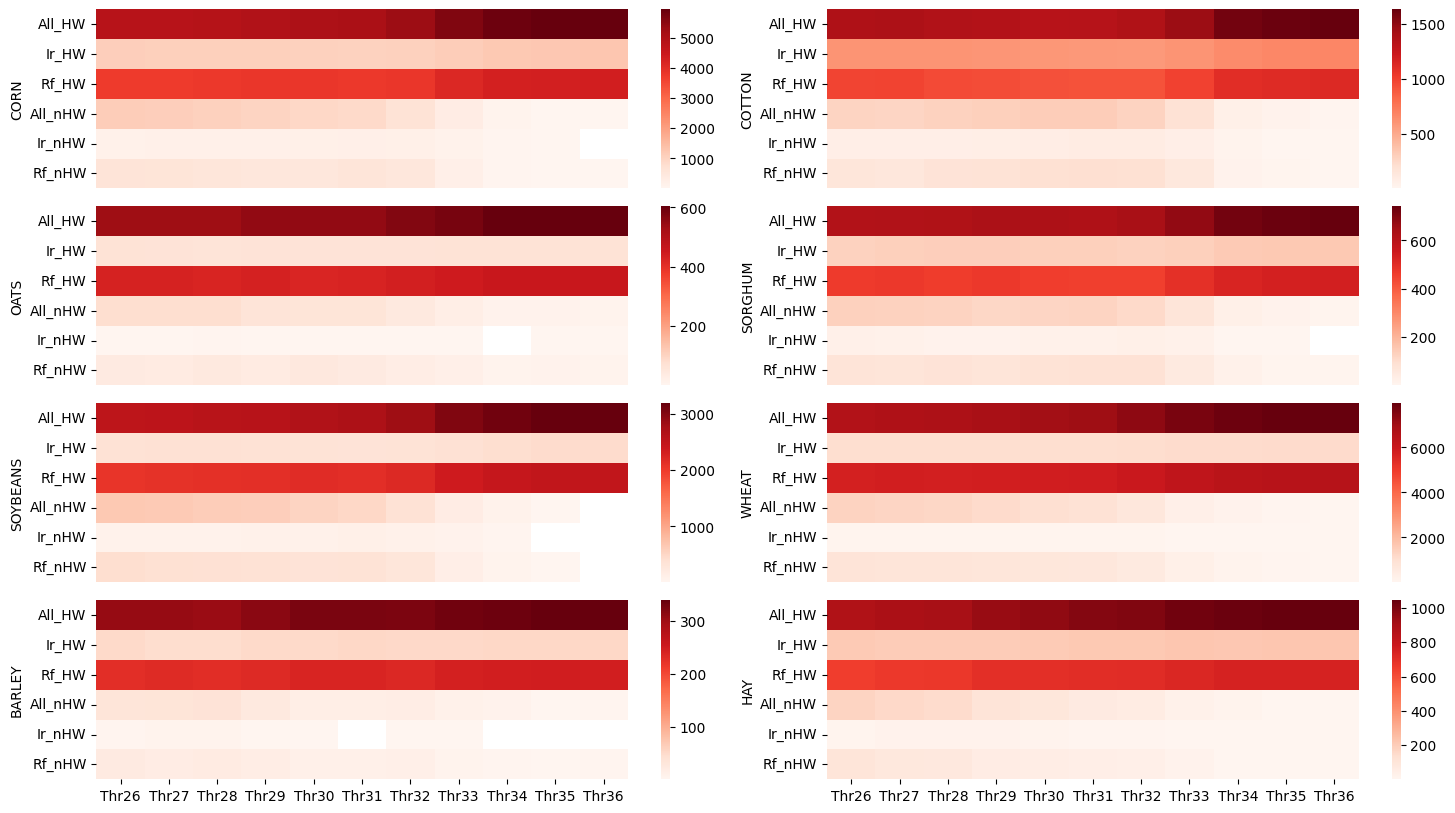

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

crops = ['CORN', 'COTTON', 'OATS', 'SORGHUM', 'SOYBEANS', 'WHEAT', 'BARLEY', 'HAY']
# dict_df_crop
fig , axes = plt.subplots(4,2,figsize=(18, 10))
axes = axes.flatten()

for i , ax in enumerate(axes):
  df = dict_df_crop[crops[i]].loc[['All_HW', 'Ir_HW', 'Rf_HW', 'All_nHW', 'Ir_nHW', 'Rf_nHW']]
  # ax = axes[i]
  sns.heatmap(df, cmap="Reds", ax=ax)
  # ax.set_title(f'{crop}')
  ax.set_xlabel('')
  ax.set_ylabel(crops[i])
  if i<6:
    ax.set_xticks([])
plt.subplots_adjust(wspace=0.1,hspace=0.1)
out_path = '<DATA_ROOT>/ProcessedData/20231117-ThrSelection-CropFailure/'
plt.savefig(out_path + 'FailureCount.png' , dpi=1200)
# plt.close()


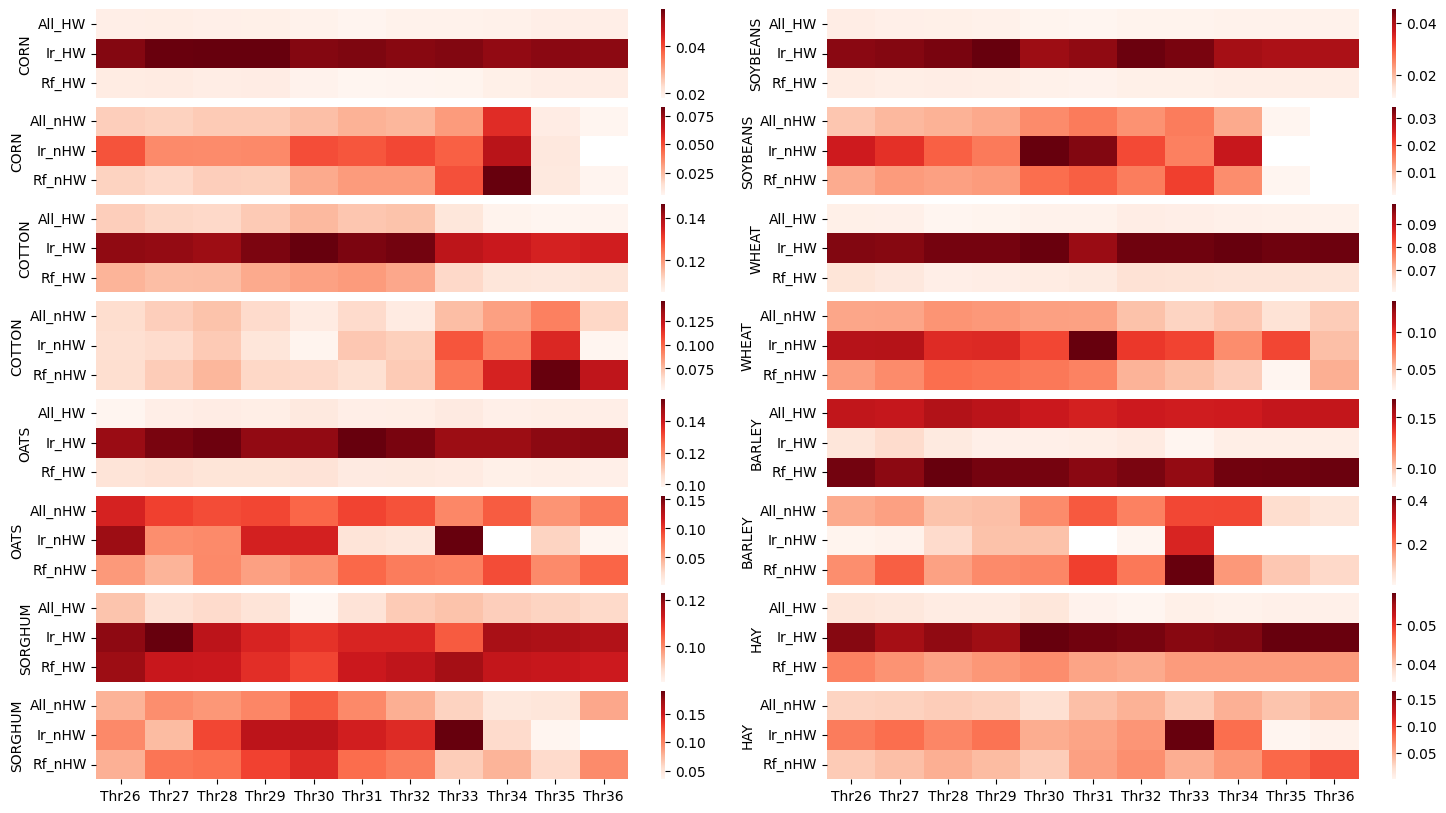

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

crops = ['CORN', 'COTTON', 'OATS', 'SORGHUM', 'SOYBEANS', 'WHEAT', 'BARLEY', 'HAY']
fig , axes = plt.subplots(8,2,figsize=(18, 10))

for i , crop in enumerate(crops):
  if i < 4:
    ax_HW = axes[2*i,0]
    ax_nHW = axes[2*i+1,0]
  else:
    ax_HW = axes[2*(i-4),1]
    ax_nHW = axes[2*(i-4)+1,1]

  df_HW = dict_df_crop[crop].loc[['All_HW', 'Ir_HW', 'Rf_HW']]
  df_nHW = dict_df_crop[crop].loc[['All_nHW', 'Ir_nHW', 'Rf_nHW']]

  sns.heatmap(df_HW, cmap="Reds", ax=ax_HW)
  sns.heatmap(df_nHW, cmap="Reds", ax=ax_nHW)
  # ax.set_title(f'{crop}')
  ax_HW.set_xlabel('')
  ax_HW.set_ylabel(crops[i])
  ax_nHW.set_xlabel('')
  ax_nHW.set_ylabel(crops[i])
  ax_HW.set_xticks([])
  if i!=3 and i!=7:
    ax_nHW.set_xticks([])
plt.subplots_adjust(wspace=0.1,hspace=0.1)
out_path = '<DATA_ROOT>/ProcessedData/20231117-ThrSelection-CropFailure/'
plt.savefig(out_path + 'FailureCount_HW_nHW.png' , dpi=1200)
# plt.close()


# **Group Bar Plot**

In [ ]:
df_group1 = df_merge.groupby(['Crop',	'Irrigation Practice', 'RPL_THEME1', 'SPEI9']).mean().reset_index()
df_group2 = df_merge.groupby(['Crop',	'Irrigation Practice', 'RPL_THEME2', 'SPEI9']).mean().reset_index()
df_group3 = df_merge.groupby(['Crop',	'Irrigation Practice', 'RPL_THEME3', 'SPEI9']).mean().reset_index()
df_group4 = df_merge.groupby(['Crop',	'Irrigation Practice', 'RPL_THEME4', 'SPEI9']).mean().reset_index()


In [ ]:
df_group1['group'] = df_group1['Crop'] + df_group1['Irrigation Practice'] #  + df_group1['SPEI9']
df_group2['group'] = df_group2['Crop'] + df_group2['Irrigation Practice'] #  + df_group2['SPEI9']
df_group3['group'] = df_group3['Crop'] + df_group3['Irrigation Practice'] #  + df_group3['SPEI9']
df_group4['group'] = df_group4['Crop'] + df_group4['Irrigation Practice'] #  + df_group4['SPEI9']

df_group1 = df_group1.drop(columns = ['Crop',	'Irrigation Practice']) # ,'SPEI9'
df_group2 = df_group2.drop(columns = ['Crop',	'Irrigation Practice']) # ,'SPEI9'
df_group3 = df_group3.drop(columns = ['Crop',	'Irrigation Practice']) # ,'SPEI9'
df_group4 = df_group4.drop(columns = ['Crop',	'Irrigation Practice']) # ,'SPEI9'


df_group1_D = df_group1[df_group1.SPEI9 == 'D']
df_group2_D = df_group2[df_group2.SPEI9 == 'D']
df_group3_D = df_group3[df_group3.SPEI9 == 'D']
df_group4_D = df_group4[df_group4.SPEI9 == 'D']

df_group1_ND = df_group1[df_group1.SPEI9 == 'ND']
df_group2_ND = df_group2[df_group2.SPEI9 == 'ND']
df_group3_ND = df_group3[df_group3.SPEI9 == 'ND']
df_group4_ND = df_group4[df_group4.SPEI9 == 'ND']

df_group1_ND.fail_share = df_group1_ND.fail_share * (-1)
df_group2_ND.fail_share = df_group2_ND.fail_share * (-1)
df_group3_ND.fail_share = df_group3_ND.fail_share * (-1)
df_group4_ND.fail_share = df_group4_ND.fail_share * (-1)

In [ ]:
# plt.figure(figsize=(30, 20))
df_group1_D.pivot(index='group',columns='RPL_THEME1',values='fail_share').plot.bar(figsize=(20, 10),width=0.7)
df_group1_ND.pivot(index='group',columns='RPL_THEME1',values='fail_share').plot.bar(figsize=(20, 10),width=0.7)


# **Diverging Bar Plot**

In [ ]:
df_group1 = df_merge.groupby(['Crop',	'Irrigation Practice', 'RPL_THEME1', 'SPEI9']).mean().reset_index()
df_group2 = df_merge.groupby(['Crop',	'Irrigation Practice', 'RPL_THEME2', 'SPEI9']).mean().reset_index()
df_group3 = df_merge.groupby(['Crop',	'Irrigation Practice', 'RPL_THEME3', 'SPEI9']).mean().reset_index()
df_group4 = df_merge.groupby(['Crop',	'Irrigation Practice', 'RPL_THEME4', 'SPEI9']).mean().reset_index()


In [ ]:
df_group1

In [ ]:
import pandas as pd
import plotly.graph_objects as go


df = df_group1[df_group1.SPEI9 == 'D']
dfi = df[df['Irrigation Practice'] == 'Ir'].pivot(index='RPL_THEME1',columns='Crop',values='fail_share')
dfr = df[df['Irrigation Practice'] == 'Rf'].pivot(index='RPL_THEME1',columns='Crop',values='fail_share')

dfr

Crop,BARLEY,CORN,COTTON,HAY,OATS,SORGHUM,SOYBEANS,WHEAT
RPL_THEME1,,,,,,,,
1,0.129583,0.007509,0.229640,0.040285,0.073818,0.073921,0.005484,0.062625
2,0.179849,0.011946,0.129787,0.036465,0.115023,0.081193,0.008711,0.063812
3,0.200576,0.022939,0.110785,0.063665,0.116514,0.139268,0.014523,0.070325
4,0.274738,0.042524,0.090593,0.057051,0.147676,0.120716,0.023772,0.075887


# **Spider Plot**

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import geopandas as gpd
from matplotlib import pyplot as plt
import seaborn as sns
from glob import glob

In [ ]:
fpath1 = '<DATA_ROOT>/WeatherIndex/Temp_Tercile_11nov.csv'
fpath2 = '<DATA_ROOT>/WeatherIndex/Drought_Map.csv'
# dft = pd.read_csv(fpath1)
dfd = pd.read_csv(fpath2)

dfd = dfd.rename(columns={'Year':'year', 'STATE':'State', 'COUNTY':'County'})
fpath = '<DATA_ROOT>/WeatherIndex/svi2020fips.csv'
df_fips_obj = pd.read_csv(fpath)[['FIPS',	'OBJECTID']]
dfd = pd.merge(dfd,df_fips_obj,on=['OBJECTID']).drop(columns=['State','County','OBJECTID'])
dfd = dfd.set_index(['FIPS','year'])
dfd[dfd == 0] = 1

dfd.iloc[0:5,:]

# dft = dft.rename(columns={'Year':'year'}).drop(columns=['State','County'])
# fpath = '<DATA_ROOT>/WeatherIndex/svi2020fips.csv'
# df_fips_obj = pd.read_csv(fpath)[['FIPS',	'OBJECTID']]
# dft = pd.merge(dft,df_fips_obj,on=['OBJECTID'])
# dft.iloc[0:5,:]

In [ ]:
import pandas as pd
fsvi = '<DATA_ROOT>/SVI/SVI_timeseries.csv'
df_svi = pd.read_csv(fsvi)
# df_svi = df_svi.sort_values(by=['State', 'County'])
df_svi = df_svi.drop(columns=['State', 'County'])
df_svi = df_svi.set_index(['FIPS','year'])
df_svi

In [ ]:
# df_svi = df_svi.set_index(['FIPS','year'])
bins = [0, 0.25, 0.5, 0.75, 1]
labels = [1, 2, 3, 4]
df_svi = df_svi.apply(lambda x: pd.cut(x, bins=bins, labels=labels), axis=0)
# df_svi = df_svi.reset_index()
df_svi.iloc[0:5,:]

In [ ]:
ffail = '<DATA_ROOT>/crop_failure_data/crops_failure_0595.csv'
df_fail = pd.read_csv(ffail)
df_fail = df_fail.drop(columns=['Unnamed: 0'])
df_fail = df_fail.sort_values(by=['FIPS'])
cond1 = df_fail['year']>2010
cond2 = df_fail['Planted Acres'] > 0
df_fail = df_fail[cond2]
df_fail['fail_share'] = df_fail['Failed Acres'] /  df_fail['Planted Acres']
df_fail = df_fail[df_fail.fail_share < 1]
df_fail.iloc[0:10,:]

In [ ]:
# df_fail_agg = df_fail.groupby(['FIPS','Crop','year','Irrigation Practice']).mean().reset_index()
df_merge = pd.merge(df_fail,df_svi['RPL_THEMES'],on=['FIPS','year'])
df_merge = pd.merge(df_merge,dfd['SPEI9'],on=['FIPS','year'])
# df_merge = df_merge[['FIPS', 'year', 'Crop', 'Irrigation Practice', 'fail_share', 'RPL_THEMES', 'SPEI9']]
# df_merge.loc[df_merge['SPEI9'] == 0,'SPEI9'] = 1
# df_merge = df_merge[df_merge['Irrigation Practice'] != 'ALL']
df_merge#[df_merge['SPEI9'] == 1]
df_merge = df_merge[df_merge.fail_share > 0]
df_merge

In [ ]:
df_merge_cols = df_merge.drop(columns=['FIPS', 'Planted Acres','Prevented Acres', 'Failed Acres', 'State', 'County','year'])
df_group = df_merge_cols.groupby(['Crop',	'Irrigation Practice', 'RPL_THEMES', 'SPEI9']).mean().reset_index()
df_group.iloc[0:5,:]

In [ ]:
irig = ['I' , 'N'] #'ALL' ,
irig_lbls = [ 'Irrigation' ,'Rainfed']#'All Irrigation Types' ,
themes = [1,2,3,4]
is_drought = [-1,1]
is_drought_lbls = ['Non-Drought' , 'Drought']


fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
categories = list(df_group_i.Crop)
num_cats = len(categories)
angles = np.linspace(0, 2 * np.pi, num_cats-1, endpoint=False).tolist()

values = df_group_i.fail_share.tolist()
angles += [angles[0]]

for idx_ig , ig in enumerate(irig):
  # for idx_theme , theme in enumerate(themes):
  for idx_dr , dr in enumerate(is_drought):
    cond_ig = df_group['Irrigation Practice'] == ig
    ig_lbl = irig_lbls[idx_ig]
    cond_svi = df_group['RPL_THEMES'] == 4
    cond_dr = df_group['SPEI9'] == dr
    dr_lbl = is_drought_lbls[idx_dr]

    df_group_i = df_group[cond_ig & cond_svi & cond_dr][['Crop','fail_share']]
    # df_group_i = pd.append(df_group_i , df_group_i.iloc[0,:])
    df_group_i = pd.concat([df_group_i , pd.DataFrame(df_group_i.iloc[0,:]).transpose()],axis=0)


    ax.plot(angles, df_group_i.fail_share, linewidth=2, linestyle='solid', label= ig_lbl + ' ' + 'RPL_THEMES:' + str(themes[0]) + ' ' + dr_lbl)
    plt.xticks(angles,categories)

# ax.fill(angles, values, alpha=0.25)
ax.legend(loc='upper right', bbox_to_anchor=(1.7, 1))
plt.show()

In [ ]:
df_group_i

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create a sample DataFrame
data = {
    'Category': ['A', 'B', 'C', 'D'],
    'Variable1': [4, 3, 2, 5],
    'Variable2': [3, 5, 1, 4],
    'Variable3': [2, 4, 5, 3],
}

df = pd.DataFrame(data)
df = df.set_index('Category')

# Normalize the data for better comparison
df_normalized = df / df.max()
df_normalized = df_normalized.append(df_normalized.iloc[0,:])

# Plotting
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
categories = list(df_normalized.index)
num_cats = len(categories)
angles = np.linspace(0, 2 * np.pi, num_cats-1, endpoint=False).tolist()

values = df_normalized.values.tolist()
angles += [angles[0]]

for col in df_normalized.columns:
  ax.plot(angles, df_normalized[col], linewidth=2, linestyle='solid', label=col)

ax.fill(angles, values, alpha=0.25)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.show()
